# Modelado de Recontacto (Modelo Correcto - Sin Leakage)
Este cuaderno demuestra el modelo correcto para predecir si un ciudadano volverá a contactar (recontacto_7_dias), utilizando únicamente la información disponible en el momento de la llamada.

In [1]:
import pyodbc
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from xgboost import XGBClassifier

# Cargar datos limpios
server = os.getenv('DB_SERVER', 'db')
database = os.getenv('DB_NAME', 'ServicioCiudadanoDW')
username = os.getenv('DB_USER', 'SA')
password = os.getenv('DB_PASSWORD', 'J0AhMXX4H0QBrRr8R1U098y8aA1@')
driver = os.getenv('DB_DRIVER', '{ODBC Driver 18 for SQL Server}')

connection_string = f'DRIVER={driver};SERVER={server};DATABASE={database};UID={username};PWD={password};TrustServerCertificate=yes;'
conn = pyodbc.connect(connection_string)
df = pd.read_sql("SELECT * FROM vw_v1_limpio", conn)
conn.close()

print(f"✅ Dataset cargado exitosamente")
print(f"📏 Dimensiones: {df.shape[0]:,} filas × {df.shape[1]} columnas")


/tmp/ipykernel_99/276284760.py:19: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM vw_v1_limpio", conn)


✅ Dataset cargado exitosamente
📏 Dimensiones: 73,923 filas × 14 columnas


In [2]:
# Preparar variables
X = df.drop(columns=['id_interaccion', 'fecha_contacto', 'fecha_carga', 'recontacto_7_dias'])
y = df['recontacto_7_dias']

# One-hot encoding de las categóricas
columnas_texto = X.select_dtypes(include=['object']).columns
X = pd.get_dummies(X, columns=columnas_texto.tolist(), drop_first=True)

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
print(f"✅ Set de entrenamiento: {X_train.shape[0]} | Set de prueba: {X_test.shape[0]}")


/tmp/ipykernel_99/2163815437.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  columnas_texto = X.select_dtypes(include=['object']).columns


✅ Set de entrenamiento: 59138 | Set de prueba: 14785


In [3]:
# Entrenar el modelo (XGBoost)
# Balanceo de clases
ratio_desbalance = (y_train == 0).sum() / (y_train == 1).sum()

modelo = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=ratio_desbalance, 
    random_state=42,
    eval_metric='auc'
)

print("🔄 Entrenando modelo XGBoost...")
modelo.fit(X_train, y_train)
print("✅ Modelo entrenado exitosamente")

# Evaluacion
y_pred = modelo.predict(X_test)
y_pred_proba = modelo.predict_proba(X_test)[:, 1]

print("=" * 60)
print("📊 REPORTE DE CLASIFICACIÓN (Recontacto)")
print("=" * 60)
print(classification_report(y_test, y_pred, target_names=['Resuelto (0)', 'Recontacta (1)']))
print(f"🎯 ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")


🔄 Entrenando modelo XGBoost...
✅ Modelo entrenado exitosamente
📊 REPORTE DE CLASIFICACIÓN (Recontacto)
                precision    recall  f1-score   support

  Resuelto (0)       0.69      0.52      0.59      8839
Recontacta (1)       0.48      0.65      0.55      5946

      accuracy                           0.57     14785
     macro avg       0.58      0.58      0.57     14785
  weighted avg       0.60      0.57      0.57     14785

🎯 ROC-AUC Score: 0.5914


/tmp/ipykernel_99/178285746.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Variable', data=importancia, palette='viridis', ax=axes[1])


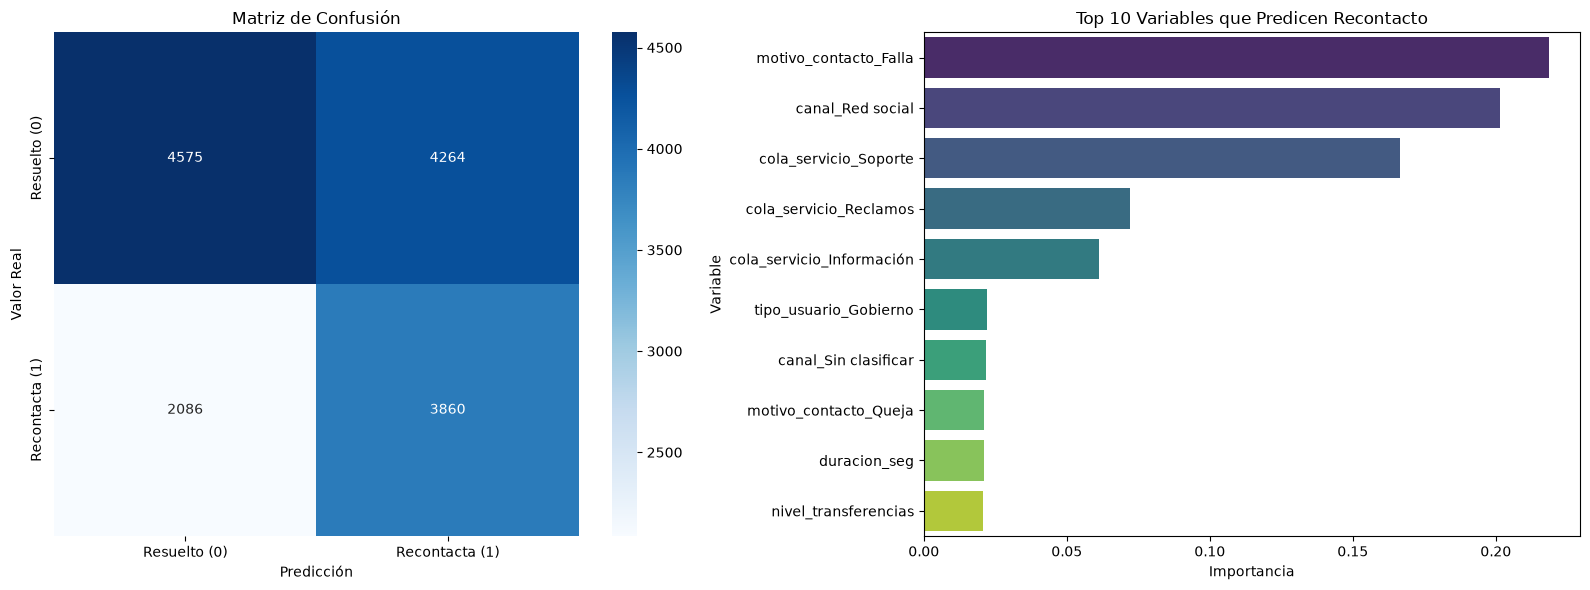

In [4]:
# Gráfico de Matriz de Confusión y Feature Importance
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Matriz
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Resuelto (0)', 'Recontacta (1)'], 
            yticklabels=['Resuelto (0)', 'Recontacta (1)'], ax=axes[0])
axes[0].set_title('Matriz de Confusión')
axes[0].set_ylabel('Valor Real')
axes[0].set_xlabel('Predicción')

# Importancia
importancia = pd.DataFrame({'Variable': X.columns, 'Importancia': modelo.feature_importances_})
importancia = importancia.sort_values(by='Importancia', ascending=False).head(10)
sns.barplot(x='Importancia', y='Variable', data=importancia, palette='viridis', ax=axes[1])
axes[1].set_title('Top 10 Variables que Predicen Recontacto')

plt.tight_layout()
plt.show()
